In [12]:
import math
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Original labeled dataset
ORIGINAL_DATASET = Path("penguins_dataset")

# Tiled dataset for training
OUTPUT_DATASET = Path("cut_images_dataset")

# Tiled dataset for test images
OUTPUT_TEST = Path("cut_test")

# Tiled dataset for unlabeled images
UNLABELED_DATASET = Path("unlabeled")
OUTPUT_UNLABELED = Path("cut_unlabeled/images")

In [3]:
TILE_SIZE = 1024
OVERLAP = 256
MIN_VISIBLE_RATIO = 0.3

In [4]:
def yolo_to_xyxy(x, y, w, h, W, H):
    cx, cy = x * W, y * H
    bw, bh = w * W, h * H
    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2
    return x1, y1, x2, y2


def xyxy_to_yolo(x1, y1, x2, y2, W, H):
    bw = x2 - x1
    bh = y2 - y1
    cx = x1 + bw / 2
    cy = y1 + bh / 2
    return cx / W, cy / H, bw / W, bh / H

In [ ]:
def tile_image(image_path, label_path, out_img_dir, out_lbl_dir=None):

    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    boxes = []

    if label_path and label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            c, x, y, w, h = line.split()
            c = int(c)
            x, y, w, h = map(float, (x, y, w, h))

            x1, y1, x2, y2 = yolo_to_xyxy(x, y, w, h, W, H)
            area = (x2 - x1) * (y2 - y1)

            boxes.append((c, x1, y1, x2, y2, area))

    stride = TILE_SIZE - OVERLAP

    nx = math.ceil((W - TILE_SIZE) / stride) + 1
    ny = math.ceil((H - TILE_SIZE) / stride) + 1

    tile_index = 0

    for iy in range(ny):
        for ix in range(nx):

            left = ix * stride
            top = iy * stride
            right = min(left + TILE_SIZE, W)
            bottom = min(top + TILE_SIZE, H)

            if right - left < TILE_SIZE and W >= TILE_SIZE:
                left = W - TILE_SIZE
                right = W

            if bottom - top < TILE_SIZE and H >= TILE_SIZE:
                top = H - TILE_SIZE
                bottom = H

            tile = img.crop((left, top, right, bottom))
            tW, tH = tile.size

            new_name = f"{image_path.stem}_tile_{tile_index:04d}.jpg"
            tile.save(out_img_dir / new_name, quality=95)

            if out_lbl_dir:

                tile_labels = []

                for (c, x1, y1, x2, y2, original_area) in boxes:

                    ix1 = max(x1, left)
                    iy1 = max(y1, top)
                    ix2 = min(x2, right)
                    iy2 = min(y2, bottom)

                    if ix2 <= ix1 or iy2 <= iy1:
                        continue

                    visible_area = (ix2 - ix1) * (iy2 - iy1)

                    if visible_area / original_area < MIN_VISIBLE_RATIO:
                        continue

                    lx1 = ix1 - left
                    ly1 = iy1 - top
                    lx2 = ix2 - left
                    ly2 = iy2 - top

                    x, y, w, h = xyxy_to_yolo(lx1, ly1, lx2, ly2, tW, tH)

                    tile_labels.append(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

                label_file = out_lbl_dir / f"{Path(new_name).stem}.txt"

                if tile_labels:
                    label_file.write_text("\n".join(tile_labels) + "\n")
                else:
                    label_file.touch()

            tile_index += 1

In [6]:
def process_dataset(img_dir, lbl_dir, out_img_dir, out_lbl_dir=None):

    out_img_dir.mkdir(parents=True, exist_ok=True)

    if out_lbl_dir:
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.JPG")) + list(img_dir.glob("*.png"))

    for img_path in tqdm(images):

        label_path = None
        if lbl_dir:
            label_path = lbl_dir / f"{img_path.stem}.txt"

        tile_image(img_path, label_path, out_img_dir, out_lbl_dir)

In [8]:
for split in ["train", "val"]:

    process_dataset(
        ORIGINAL_DATASET / "images" / split,
        ORIGINAL_DATASET / "labels" / split,
        OUTPUT_DATASET / "images" / split,
        OUTPUT_DATASET / "labels" / split
    )

100%|██████████| 100/100 [00:25<00:00,  3.93it/s]


In [9]:
process_dataset(
    Path("test/images"),
    Path("test/labels"),
    OUTPUT_TEST / "images" / "test",
    OUTPUT_TEST / "labels" / "test"
)

100%|██████████| 2/2 [00:00<00:00,  3.79it/s]


In [10]:
process_dataset(
    UNLABELED_DATASET,
    None,
    OUTPUT_UNLABELED
)

100%|██████████| 177/177 [00:43<00:00,  4.09it/s]


In [13]:
def show_random_tiles(dataset_root, split="train", num_samples=4):

    img_dir = Path(dataset_root)/"images"/split
    lbl_dir = Path(dataset_root)/"labels"/split

    images=list(img_dir.glob("*.jpg"))
    samples=random.sample(images,min(num_samples,len(images)))

    for img_path in samples:

        img=Image.open(img_path)
        W,H=img.size

        fig,ax=plt.subplots(1,figsize=(8,8))
        ax.imshow(img)

        label_path=lbl_dir/f"{img_path.stem}.txt"

        if label_path.exists():

            for line in label_path.read_text().strip().splitlines():

                c,x,y,w,h=line.split()
                x,y,w,h=map(float,(x,y,w,h))

                bw=w*W
                bh=h*H
                cx=x*W
                cy=y*H

                x1=cx-bw/2
                y1=cy-bh/2

                rect=patches.Rectangle(
                    (x1,y1),bw,bh,
                    linewidth=1.5,
                    edgecolor='red',
                    facecolor='none'
                )

                ax.add_patch(rect)

        ax.axis("off")
        plt.show()

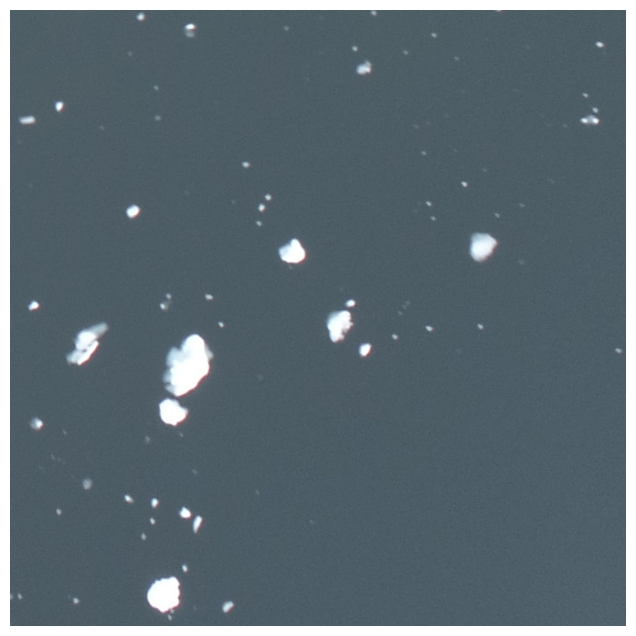

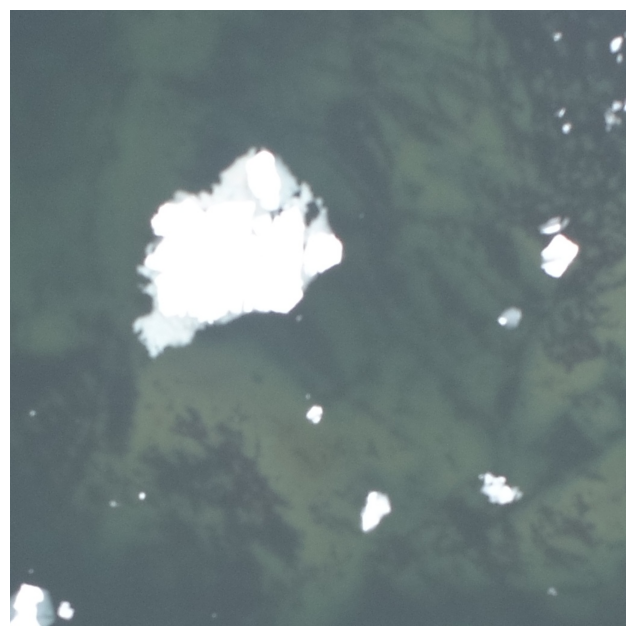

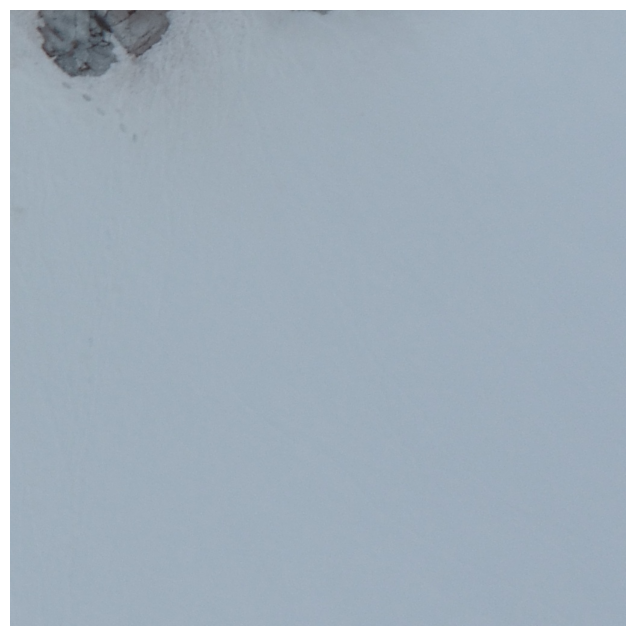

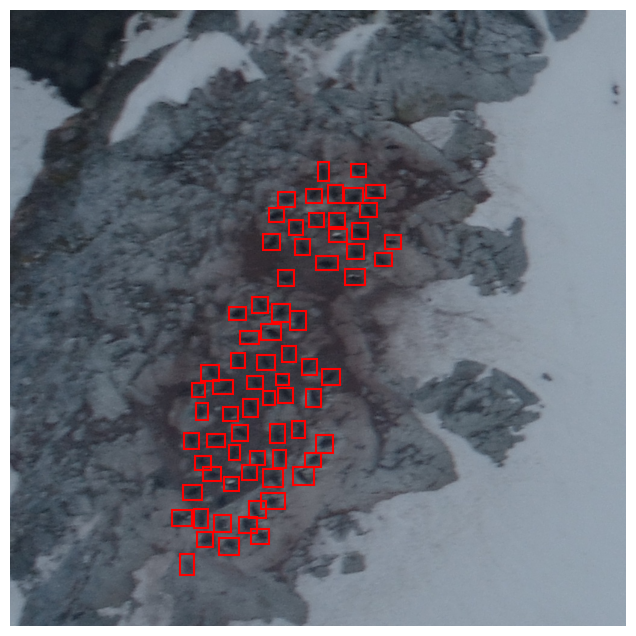

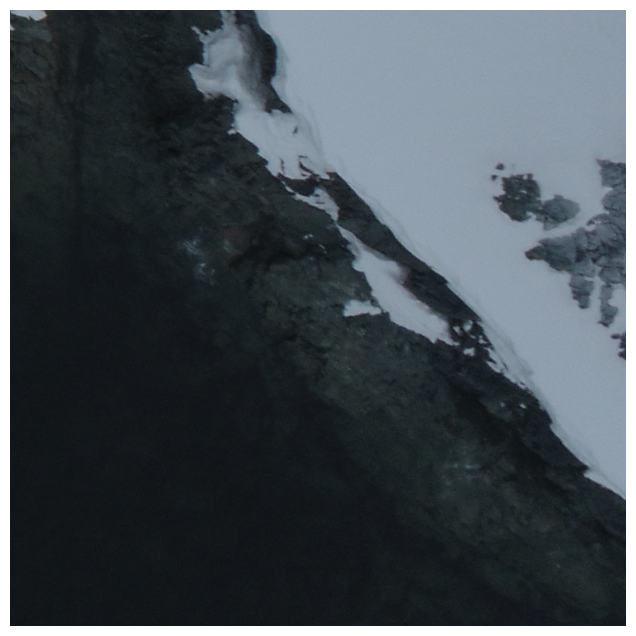

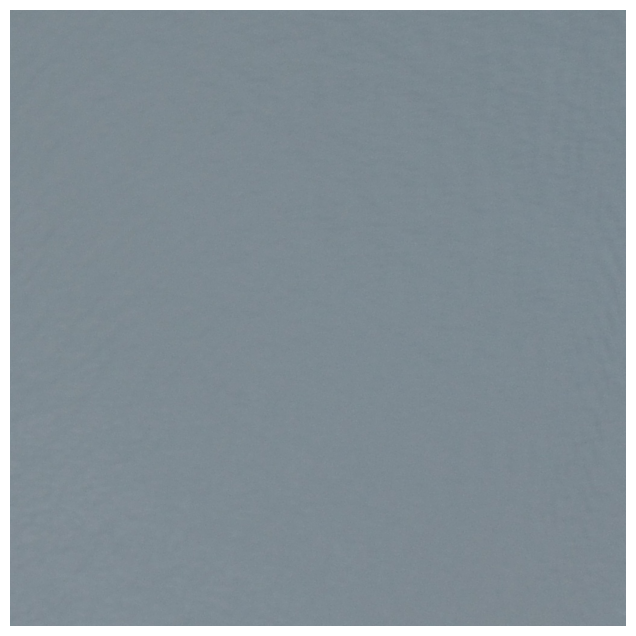

In [14]:
show_random_tiles("cut_images_dataset","train",6)

In [15]:
def count_empty_label_files(dataset_root, split):

    lbl_dir=Path(dataset_root)/"labels"/split
    label_files=list(lbl_dir.glob("*.txt"))

    empty=sum(1 for f in label_files if f.read_text().strip()=="")

    print(f"{split}: {empty}/{len(label_files)} empty ({empty/len(label_files)*100:.2f}%)")

In [16]:
def balance_dataset(dataset_root, split, target_empty_ratio=0.2):

    img_dir=Path(dataset_root)/"images"/split
    lbl_dir=Path(dataset_root)/"labels"/split

    label_files=list(lbl_dir.glob("*.txt"))

    empty=[f for f in label_files if f.read_text().strip()==""]
    non_empty=[f for f in label_files if f.read_text().strip()!=""]

    target=int((target_empty_ratio/(1-target_empty_ratio))*len(non_empty))

    if target>=len(empty):
        return

    keep=set(random.sample(empty,target))

    for f in empty:
        if f not in keep:
            (img_dir/f"{f.stem}.jpg").unlink(missing_ok=True)
            f.unlink()

In [17]:
balance_dataset("cut_images_dataset","train",0.2)
balance_dataset("cut_images_dataset","val",0.2)

In [18]:
def check_empty_labels(dataset_root, split=None):
    """
    Calculate percentage of empty label files.

    Parameters
    ----------
    dataset_root : str or Path
        Root dataset folder (e.g. "cut_images_dataset")

    split : str or None
        Dataset split ("train", "val", "test") or None to check all splits
    """

    dataset_root = Path(dataset_root)

    splits = [split] if split else ["train", "val", "test"]

    for s in splits:

        lbl_dir = dataset_root / "labels" / s

        if not lbl_dir.exists():
            print(f"Split '{s}' does not exist")
            continue

        label_files = list(lbl_dir.glob("*.txt"))

        if not label_files:
            print(f"{s}: no label files found")
            continue

        empty_count = sum(
            1 for f in label_files if f.read_text().strip() == ""
        )

        total = len(label_files)
        percentage = 100 * empty_count / total

        print(f"{s}")
        print(f"Total labels: {total}")
        print(f"Empty labels: {empty_count}")
        print(f"Percentage empty: {percentage:.2f}%\n")

In [19]:
check_empty_labels("cut_images_dataset", "train")

train
Total labels: 1487
Empty labels: 297
Percentage empty: 19.97%



In [20]:
check_empty_labels("cut_images_dataset", "val")

val
Total labels: 450
Empty labels: 90
Percentage empty: 20.00%

